In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import scienceplots

plt.style.use(['science','no-latex'])

In [4]:
lf_data = 'logs'
lf_paths = os.listdir(lf_data)
lf_paths = [f for f in lf_paths if f.endswith('.csv') and f.startswith('test') and '_b0' in f]
lf_paths

['test_log_PT_BS+C_b090.csv',
 'test_log_PT_BS+C_b040.csv',
 'test_log_PT_BS+C_b030.csv',
 'test_log_PT_BS+C_b020.csv',
 'test_log_PT_BS+C_b010.csv',
 'test_log_PT_BS+C_b000.csv']

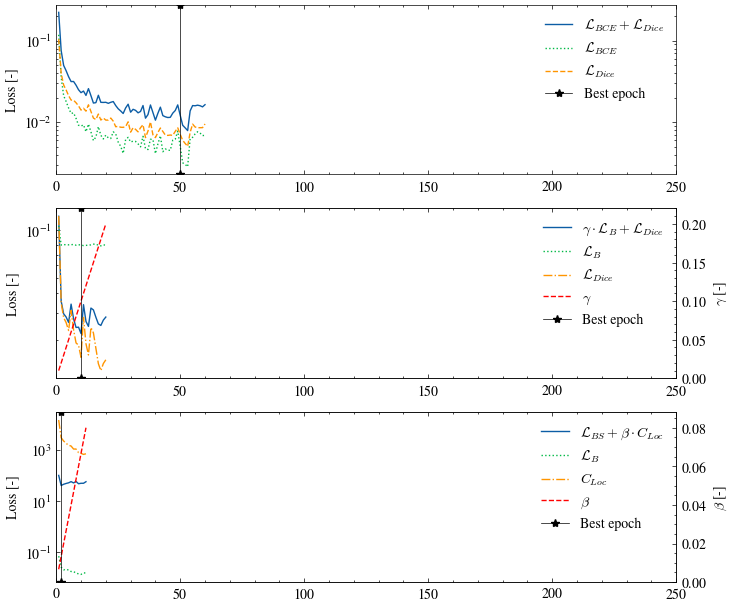

In [21]:
factor = 3 #len(lf_paths)
fig, axes = plt.subplots(factor, figsize=(8, 2.5*factor))

for lf_path in lf_paths:
    # if 'Focal' in lf_path:
    #     i=0
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data+lf_path)
    #     axes[i].plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{Focal}$')
    #     #axes[i].set_xlabel('Epoch [-]')
    #     axes[i].set_xlim(0,250)
    #     axes[i].set_ylabel(r'Loss [-]')
    #     axes[i].set_yscale('log')
    #     axes[i].axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     axes[i].legend()

    # if 'Distance' in lf_path:
    #     i=2
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data+lf_path)
    #     axes[i].plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{Dist}$')
    #     #axes[i].set_xlabel('Epoch [-]')
    #     axes[i].set_xlim(0,250)
    #     axes[i].set_ylabel(r'Loss [-]')
    #     axes[i].set_yscale('log')
    #     axes[i].axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     axes[i].legend()

    if 'BCE+Dice' in lf_path:
        i=0
        best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
        data = pd.read_csv(lf_data+lf_path)
        axes[i].plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{BCE}+\mathcal{L}_{Dice}$')
        axes[i].plot(data.epoch, data.train_loss-(1-data.train_dice/100), label=r'$\mathcal{L}_{BCE}$', linestyle=':')
        axes[i].plot(data.epoch, 1-data.train_dice/100, label=r'$\mathcal{L}_{Dice}$', linestyle='--')
        #axes[i].set_xlabel('Epoch [-]')
        axes[i].set_xlim(0,250)
        axes[i].set_ylabel(r'Loss [-]')
        axes[i].set_yscale('log')
        axes[i].axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
        axes[i].legend()

    # if 'HD+Dice' in lf_path:
    #     i=3
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data + lf_path)
    
    #     ax1 = axes[i]                          # left axis
    #     ax2 = ax1.twinx()                      # right axis (for lambda)
    
    #     # ----- Left axis: log-scaled losses -----
    #     ax1.plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{HD}+\lambda\cdot \mathcal{L}_{Dice}$')
    #     ax1.plot(data.epoch, data.train_hd,   label=r'$\mathcal{L}_{HD}$', linestyle='-.')
    #     ax1.plot(data.epoch, data.train_dsc,  label=r'$\mathcal{L}_{Dice}$', linestyle=':')
    
    #     #ax1.set_xlabel('Epoch [-]')
    #     ax1.set_ylabel(r'Loss [-]')
    #     ax1.set_yscale('log')
    #     ax1.set_xlim(0, 250)
    
    #     # ----- Right axis: lambda (linear scale) -----
    #     ax2.plot(data.epoch, data.train_lmbda, color='red', linestyle='--', label=r'$\lambda$')
    #     ax2.set_ylabel(r'$\lambda$ [-]')
    #     ax2.set_ylim(0, data.train_lmbda.max() * 1.1)
    #     ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     # ----- Combined legend -----
    #     # Collect handles from both axes
    #     lines_1, labels_1 = ax1.get_legend_handles_labels()
    #     lines_2, labels_2 = ax2.get_legend_handles_labels()
    #     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    if 'B+Dice' in lf_path:
        i=1
        best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
        data = pd.read_csv(lf_data + lf_path)
    
        ax1 = axes[i]                          # left axis
        ax2 = ax1.twinx()                      # right axis (for lambda)
    
        # ----- Left axis: log-scaled losses -----
        ax1.plot(data.epoch, data.train_loss, label=r'$\gamma\cdot \mathcal{L}_{B}+\mathcal{L}_{Dice}$')
        ax1.plot(data.epoch, data.train_b,   label=r'$\mathcal{L}_{B}$', linestyle=':')
        ax1.plot(data.epoch, data.train_dsc,  label=r'$\mathcal{L}_{Dice}$', linestyle='-.')
    
        #ax1.set_xlabel('Epoch [-]')
        ax1.set_ylabel(r'Loss [-]')
        ax1.set_yscale('log')
        ax1.set_xlim(0, 250)
    
        # ----- Right axis: lambda (linear scale) -----
        ax2.plot(data.epoch, data.train_alpha, color='red', linestyle='--', label=r'$\gamma$')
        ax2.set_ylabel(r'$\gamma$ [-]')
        ax2.set_ylim(0, data.train_alpha.max() * 1.1)
        ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
        # ----- Combined legend -----
        # Collect handles from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    if 'BS+C_' in lf_path:
        i=2
        best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
        data = pd.read_csv(lf_data + lf_path)
    
        ax1 = axes[i]                          # left axis
        ax2 = ax1.twinx()                      # right axis (for lambda)
    
        # ----- Left axis: log-scaled losses -----
        ax1.plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{BS}+\beta\cdot C_{Loc}$')
        ax1.plot(data.epoch, data.train_bs,   label=r'$\mathcal{L}_{B}$', linestyle=':')
        ax1.plot(data.epoch, data.train_cloc,  label=r'$C_{Loc}$', linestyle='-.')
    
        #ax1.set_xlabel('Epoch [-]')
        ax1.set_ylabel(r'Loss [-]')
        ax1.set_yscale('log')
        ax1.set_xlim(0, 250)
    
        # ----- Right axis: lambda (linear scale) -----
        ax2.plot(data.epoch, data.train_beta, color='red', linestyle='--', label=r'$\beta$')
        ax2.set_ylabel(r'$\beta$ [-]')
        ax2.set_ylim(0, data.train_beta.max() * 1.1)
        ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
        # ----- Combined legend -----
        # Collect handles from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # if 'BS+C+FI_' in lf_path:
    #     i=6
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data + lf_path)
    
    #     ax1 = axes[i]                          # left axis
    #     ax2 = ax1.twinx()                      # right axis (for lambda)
    
    #     # ----- Left axis: log-scaled losses -----
    #     ax1.plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{BS}+\beta\cdot (C_{Loc}+FI)$')
    #     ax1.plot(data.epoch, data.train_bs,   label=r'$\mathcal{L}_{B}$', linestyle=':')
    #     ax1.plot(data.epoch, data.train_cloc,  label=r'$C_{Loc}$', linestyle='-.')
    #     ax1.plot(data.epoch, data.train_fi,  label=r'$FI$', linestyle='--')
    
    #     ax1.set_xlabel('Epoch [-]')
    #     ax1.set_ylabel(r'Loss [-]')
    #     ax1.set_yscale('log')
    #     ax1.set_xlim(0, 250)
    
    #     # ----- Right axis: lambda (linear scale) -----
    #     ax2.plot(data.epoch, data.train_beta, color='red', linestyle='--', label=r'$\beta$')
    #     ax2.set_ylabel(r'$\beta$ [-]')
    #     ax2.set_ylim(0, data.train_beta.max() * 1.1)
    #     ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     # ----- Combined legend -----
    #     # Collect handles from both axes
    #     lines_1, labels_1 = ax1.get_legend_handles_labels()
    #     lines_2, labels_2 = ax2.get_legend_handles_labels()
    #     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # if 'BCE+BS+C+FI_' in lf_path:
    #     i=7
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data + lf_path)
    
    #     ax1 = axes[i]                          # left axis
    #     ax2 = ax1.twinx()                      # right axis (for lambda)
    
    #     # ----- Left axis: log-scaled losses -----
    #     ax1.plot(data.epoch, data.train_loss, label=r'$\mathcal{L}_{BCE}+\mathcal{L}_{BS}+\beta\cdot (C_{Loc}+FI)$')
    #     ax1.plot(data.epoch, data.train_bs,   label=r'$\mathcal{L}_{B}$', linestyle=':')
    #     ax1.plot(data.epoch, data.train_cloc,  label=r'$C_{Loc}$', linestyle='-.')
    #     ax1.plot(data.epoch, data.train_fi,  label=r'$FI$', linestyle='--')
    
    #     ax1.set_xlabel('Epoch [-]')
    #     ax1.set_ylabel(r'Loss [-]')
    #     ax1.set_yscale('log')
    #     ax1.set_xlim(0, 250)
    
    #     # ----- Right axis: lambda (linear scale) -----
    #     ax2.plot(data.epoch, data.train_beta, color='red', linestyle='--', label=r'$\beta$')
    #     ax2.set_ylabel(r'$\beta$ [-]')
    #     ax2.set_ylim(0, data.train_beta.max() * 1.1)
    #     ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     # ----- Combined legend -----
    #     # Collect handles from both axes
    #     lines_1, labels_1 = ax1.get_legend_handles_labels()
    #     lines_2, labels_2 = ax2.get_legend_handles_labels()
    #     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.savefig('LF_PT_Training.pdf', bbox_inches='tight')
plt.savefig('LF_PT_Training.png', bbox_inches='tight')

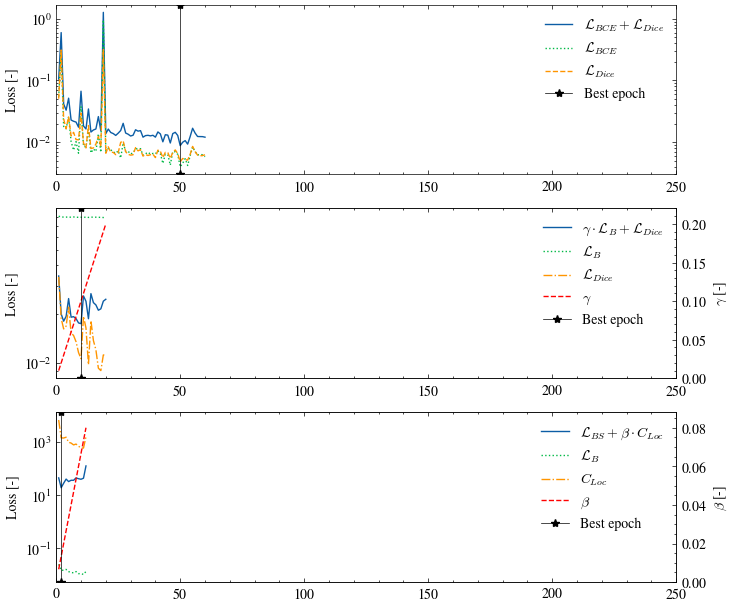

In [22]:
fig, axes = plt.subplots(factor, figsize=(8, 2.5*factor))

for lf_path in lf_paths:
    # if 'Focal' in lf_path:
    #     i=0
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data+lf_path)
    #     axes[i].plot(data.epoch, data.val_loss, label=r'$\mathcal{L}_{Focal}$')
    #     #axes[i].set_xlabel('Epoch [-]')
    #     axes[i].set_xlim(0,250)
    #     axes[i].set_ylabel(r'Loss [-]')
    #     axes[i].set_yscale('log')
    #     axes[i].axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     axes[i].legend()

    # if 'Distance' in lf_path:
    #     i=2
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data+lf_path)
    #     axes[i].plot(data.epoch, data.val_loss, label=r'$\mathcal{L}_{Dist}$')
    #     #axes[i].set_xlabel('Epoch [-]')
    #     axes[i].set_xlim(0,250)
    #     axes[i].set_ylabel(r'Loss [-]')
    #     axes[i].set_yscale('log')
    #     axes[i].axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     axes[i].legend()

    if 'BCE+Dice' in lf_path:
        i=0
        best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
        data = pd.read_csv(lf_data+lf_path)
        axes[i].plot(data.epoch, data.val_loss, label=r'$\mathcal{L}_{BCE}+\mathcal{L}_{Dice}$')
        axes[i].plot(data.epoch, data.val_loss-(1-data.val_dice/100), label=r'$\mathcal{L}_{BCE}$', linestyle=':')
        axes[i].plot(data.epoch, 1-data.val_dice/100, label=r'$\mathcal{L}_{Dice}$', linestyle='--')
        #axes[i].set_xlabel('Epoch [-]')
        axes[i].set_xlim(0,250)
        axes[i].set_ylabel(r'Loss [-]')
        axes[i].set_yscale('log')
        axes[i].axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
        axes[i].legend()

    # if 'HD+Dice' in lf_path:
    #     i=3
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data + lf_path)
    
    #     ax1 = axes[i]                          # left axis
    #     ax2 = ax1.twinx()                      # right axis (for lambda)
    
    #     # ----- Left axis: log-scaled losses -----
    #     ax1.plot(data.epoch, data.val_loss, label=r'$\mathcal{L}_{HD}+\lambda\cdot \mathcal{L}_{Dice}$')
    #     ax1.plot(data.epoch, data.val_hd,   label=r'$\mathcal{L}_{HD}$', linestyle='-.')
    #     ax1.plot(data.epoch, data.val_dsc,  label=r'$\mathcal{L}_{Dice}$', linestyle=':')
    
    #     #ax1.set_xlabel('Epoch [-]')
    #     ax1.set_ylabel(r'Loss [-]')
    #     ax1.set_yscale('log')
    #     ax1.set_xlim(0, 250)
    
    #     # ----- Right axis: lambda (linear scale) -----
    #     ax2.plot(data.epoch, data.train_lmbda, color='red', linestyle='--', label=r'$\lambda$')
    #     ax2.set_ylabel(r'$\lambda$ [-]')
    #     ax2.set_ylim(0, data.train_lmbda.max() * 1.1)
    #     ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     # ----- Combined legend -----
    #     # Collect handles from both axes
    #     lines_1, labels_1 = ax1.get_legend_handles_labels()
    #     lines_2, labels_2 = ax2.get_legend_handles_labels()
    #     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    if 'B+Dice' in lf_path:
        i=1
        best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
        data = pd.read_csv(lf_data + lf_path)
    
        ax1 = axes[i]                          # left axis
        ax2 = ax1.twinx()                      # right axis (for lambda)
    
        # ----- Left axis: log-scaled losses -----
        ax1.plot(data.epoch, data.val_loss, label=r'$\gamma\cdot \mathcal{L}_{B}+\mathcal{L}_{Dice}$')
        ax1.plot(data.epoch, data.val_b,   label=r'$\mathcal{L}_{B}$', linestyle=':')
        ax1.plot(data.epoch, data.val_dsc,  label=r'$\mathcal{L}_{Dice}$', linestyle='-.')
    
        #ax1.set_xlabel('Epoch [-]')
        ax1.set_ylabel(r'Loss [-]')
        ax1.set_yscale('log')
        ax1.set_xlim(0, 250)
    
        # ----- Right axis: lambda (linear scale) -----
        ax2.plot(data.epoch, data.train_alpha, color='red', linestyle='--', label=r'$\gamma$')
        ax2.set_ylabel(r'$\gamma$ [-]')
        ax2.set_ylim(0, data.train_alpha.max() * 1.1)
        ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
        # ----- Combined legend -----
        # Collect handles from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    if 'BS+C_' in lf_path:
        i=2
        best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
        data = pd.read_csv(lf_data + lf_path)
    
        ax1 = axes[i]                          # left axis
        ax2 = ax1.twinx()                      # right axis (for lambda)
    
        # ----- Left axis: log-scaled losses -----
        ax1.plot(data.epoch, data.val_loss, label=r'$\mathcal{L}_{BS}+\beta\cdot C_{Loc}$')
        ax1.plot(data.epoch, data.val_bs,   label=r'$\mathcal{L}_{B}$', linestyle=':')
        ax1.plot(data.epoch, data.val_cloc,  label=r'$C_{Loc}$', linestyle='-.')
    
        #ax1.set_xlabel('Epoch [-]')
        ax1.set_ylabel(r'Loss [-]')
        ax1.set_yscale('log')
        ax1.set_xlim(0, 250)
    
        # ----- Right axis: lambda (linear scale) -----
        ax2.plot(data.epoch, data.train_beta, color='red', linestyle='--', label=r'$\beta$')
        ax2.set_ylabel(r'$\beta$ [-]')
        ax2.set_ylim(0, data.train_beta.max() * 1.1)
        ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
        # ----- Combined legend -----
        # Collect handles from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # if 'BS+C+FI' in lf_path:
    #     i=6
    #     best_epoch = int(lf_path.split('.')[0].split('_')[-1][1:])
    #     data = pd.read_csv(lf_data + lf_path)
    
    #     ax1 = axes[i]                          # left axis
    #     ax2 = ax1.twinx()                      # right axis (for lambda)
    
    #     # ----- Left axis: log-scaled losses -----
    #     ax1.plot(data.epoch, data.val_loss, label=r'$\mathcal{L}_{BS}+\beta\cdot (C_{Loc}+FI)$')
    #     ax1.plot(data.epoch, data.val_bs,   label=r'$\mathcal{L}_{B}$', linestyle=':')
    #     ax1.plot(data.epoch, data.val_cloc,  label=r'$C_{Loc}$', linestyle='-.')
    #     ax1.plot(data.epoch, data.val_fi,  label=r'$FI$', linestyle='--')
    
    #     ax1.set_xlabel('Epoch [-]')
    #     ax1.set_ylabel(r'Loss [-]')
    #     ax1.set_yscale('log')
    #     ax1.set_xlim(0, 250)
    
    #     # ----- Right axis: lambda (linear scale) -----
    #     ax2.plot(data.epoch, data.train_beta, color='red', linestyle='--', label=r'$\beta$')
    #     ax2.set_ylabel(r'$\beta$ [-]')
    #     ax2.set_ylim(0, data.train_beta.max() * 1.1)
    #     ax2.axvline(x=best_epoch, color='black', label='Best epoch', linewidth=0.5, marker='*')
    #     # ----- Combined legend -----
    #     # Collect handles from both axes
    #     lines_1, labels_1 = ax1.get_legend_handles_labels()
    #     lines_2, labels_2 = ax2.get_legend_handles_labels()
    #     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.savefig('LF_PT_Validation.pdf', bbox_inches='tight')
plt.savefig('LF_PT_Validation.png', bbox_inches='tight')

In [7]:
lf_data = 'logs/'
lf_paths = os.listdir(lf_data)
lf_paths = [f for f in lf_paths if f.endswith('.csv') and f.startswith('test') and '_b0' in f]
lf_paths

['test_log_PT_BS+C_b090.csv',
 'test_log_PT_BS+C_b040.csv',
 'test_log_PT_BS+C_b030.csv',
 'test_log_PT_BS+C_b020.csv',
 'test_log_PT_BS+C_b010.csv',
 'test_log_PT_BS+C_b000.csv']

In [12]:
df = pd.DataFrame()
for lf_path in lf_paths:
    lf_name = lf_path.split('.')[0].split('_')[-1]
    data = pd.read_csv(lf_data + lf_path)
    cols = ['test_dice', 'test_precision', 'test_recall', 'test_hd95', 'test_assd', 'test_ipe', 'test_mem', 'test_flops']
    data = data[cols].iloc[:1]
    data['lf_name'] = lf_name
    df = pd.concat([df,data.round(2)])
df.set_index('lf_name', inplace=True)
df = df.sort_values(by='lf_name')

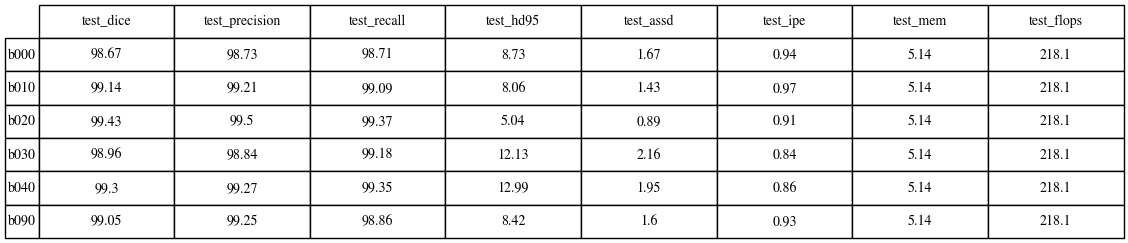

In [13]:
fix, ax = plt.subplots()
ax.axis('off')
table = pd.plotting.table(ax, df, loc='center', cellLoc='center', colWidths = [0.25]*len(df.columns))
table.scale(2,2)

#plt.save

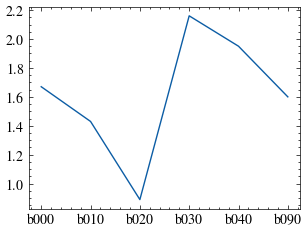

In [18]:
plt.plot(df.test_assd)

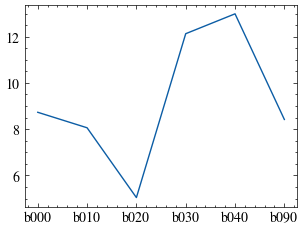

In [19]:
plt.plot(df.test_hd95)